Dado que el entrenamiento de redes neuronales es una tarea  muy costosa, **se recomienda ejecutar el notebooks en [Google Colab](https://colab.research.google.com)**, por supuesto también se puede ejecutar en local.

Al entrar en [Google Colab](https://colab.research.google.com) bastará con hacer click en `upload` y subir este notebook. No olvide luego descargarlo en `File->Download .ipynb`

**El examen deberá ser entregado con las celdas ejecutadas, si alguna celda no está ejecutadas no se contará.**

El examen se divide en preguntas de código y preguntas teóricas, con la puntuación que se indica a continuación. La puntuación máxima será 10.

- [Actividad 1: Redes Densas](#actividad_1): 10 pts
    - Correcta normalización: máximo de 0.5 pts
    - [Cuestión 1](#1.1): 1.5 pts
    - [Cuestión 2](#1.2): 1.5 pts
    - [Cuestión 3](#1.3): 1.5 pts
    - [Cuestión 4](#1.4): 1 pts
    - [Cuestión 5](#1.5): 1 pts
    - [Cuestión 6](#1.6): 1 pts
    - [Cuestión 7](#1.7): 1 pts
    - [Cuestión 8](#1.8): 1 pts


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

<a name='actividad_1'></a>
# Actividad 1: Redes Densas

Para esta actividad vamos a utilizar el [wine quality dataset](https://archive.ics.uci.edu/ml/datasets/wine+quality). Con el que trataremos de predecir la calidad del vino.

La calidad del vino puede tomar valores decimales (por ejemplo 7.25), independientemente de que en el dataset de entrenamiento sean números enteros. Por lo tanto, el problema es una `regresión`.

**Puntuación**:

Normalizar las features correctamente (x_train, x_test): 0.5 pts

- Correcta normalización: máximo de 0.5 pts
- [Cuestión 1](#1.1): 1 pt
- [Cuestión 2](#1.2): 1 pt
- [Cuestión 3](#1.3): 0.5 pts
- [Cuestión 4](#1.4): 0.5 pts
- [Cuestión 5](#1.5): 0.5 pts
- [Cuestión 6](#1.6): 0.5 pts
- [Cuestión 7](#1.7): 0.5 pts
- [Cuestión 8](#1.8): 0.5 pts



In [2]:
# Descargar los datos con pandas
df_red = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',
    sep=';'
)
df_white = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv',
    sep=';'
)
df = pd.concat([df_red, df_white])

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
feature_names = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides',
    'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'
]


# separar features y target
y = df.pop('quality').values
X = df.copy().values

In [4]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print('x_train, y_train shapes:', x_train.shape, y_train.shape)
print('x_test, y_test shapes:', x_test.shape, y_test.shape)
print('Some qualities: ', y_train[:5])

x_train, y_train shapes: (4872, 11) (4872,)
x_test, y_test shapes: (1625, 11) (1625,)
Some qualities:  [6 7 8 5 6]


In [5]:
## Si quiere, puede normalizar las features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

<a name='1.1'></a>
## Cuestión 1: Cree un modelo secuencial que contenga 4 capas ocultas(hidden layers), con más de 60 neuronas  por capa, sin regularización y obtenga los resultados.

Puntuación:
- Obtener el modelo correcto: 0.8 pts
- Compilar el modelo: 0.1pts
- Acertar con la función de pérdida: 0.1 pts

In [15]:
model = tf.keras.models.Sequential()
# Código aquí
model.add(layers.Dense(64, input_shape=(x_train.shape[1],), activation='relu'))  #  capa oculta
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dense(1, activation='linear'))  #  capa output


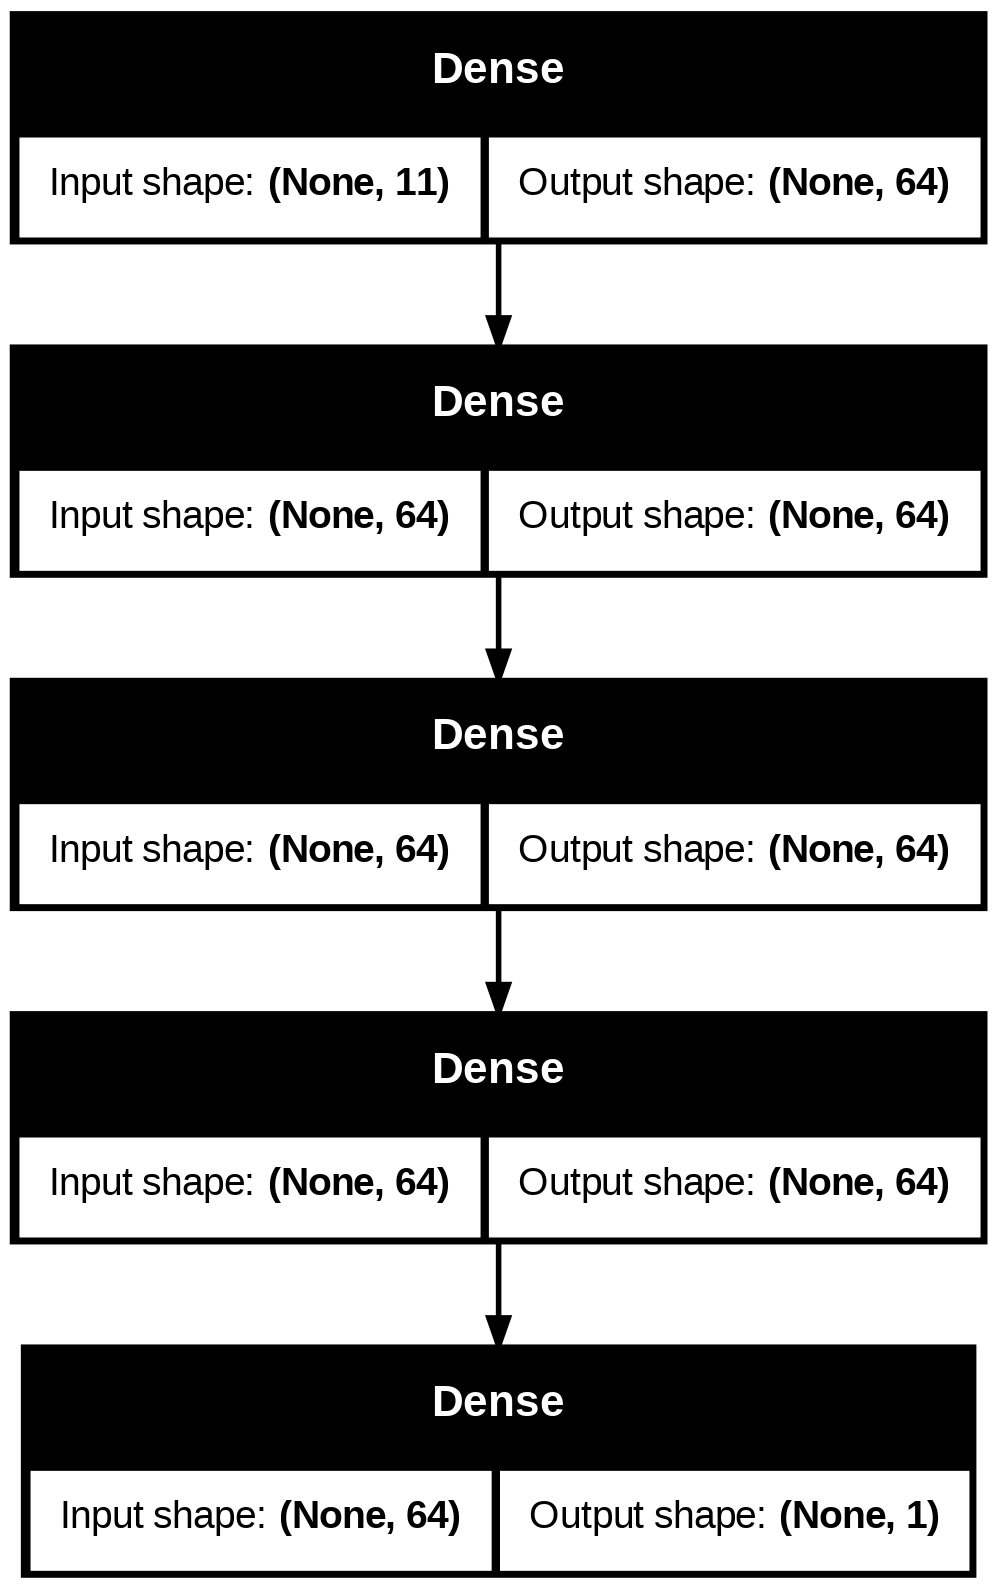

In [16]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

In [17]:
# Compilación del modelo
# Código aquí
model.compile(optimizer='adam',
              loss=tf.keras.losses.MSE,
              metrics=['mae'])

In [18]:
# No modifique el código
model.fit(x_train,
          y_train,
          epochs=200,
          batch_size=32,
          validation_split=0.2,
          verbose=1)

Epoch 1/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 14.2394 - mae: 3.0874 - val_loss: 1.7203 - val_mae: 0.9522
Epoch 2/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2154 - mae: 0.8481 - val_loss: 0.9697 - val_mae: 0.7368
Epoch 3/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7702 - mae: 0.6863 - val_loss: 0.7168 - val_mae: 0.6441
Epoch 4/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5900 - mae: 0.5945 - val_loss: 0.6235 - val_mae: 0.5998
Epoch 5/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5422 - mae: 0.5699 - val_loss: 0.5534 - val_mae: 0.5667
Epoch 6/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4936 - mae: 0.5399 - val_loss: 0.5729 - val_mae: 0.5853
Epoch 7/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4992 - mae: 0.5495 - val_loss: 0.5319 - val_mae: 0.5697
Epoch 8/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4665 - mae: 0.5259 - val_loss: 0.5150 - val_mae: 0.5586
Epoch 9/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

In [14]:
# No modifique el código
results = model.evaluate(x_test, y_test, verbose=1)
print('Test Loss: {}'.format(results))

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6850 - mae: 0.6104
Test Loss: [0.7428304553031921, 0.6303234696388245]


<a name='1.2'></a>
## Cuestión 2: Utilice el mismo modelo de la cuestión anterior pero añadiendo al menos dos técnicas distinas de regularización. No es necesario reducir el test loss.

Ejemplos de regularización: [Prevent_Overfitting.ipynb](https://github.com/ezponda/intro_deep_learning/blob/main/class/Fundamentals/Prevent_Overfitting.ipynb)

**Mis dos metodos seleccionados seran dropout y reducir el batch size**

In [19]:
model = tf.keras.models.Sequential()
# Código aquí
model.add(layers.Dense(64, input_shape=(x_train.shape[1],), activation='relu'))  #  capa oculta
model.add(layers.Dropout(0.4))
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dropout(0.4))
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dropout(0.4))
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dropout(0.4))
model.add(layers.Dense(1, activation='linear'))  #  capa output

In [20]:
# Compilación del modelo
# Código aquí
model.compile(optimizer='adam',
              loss=tf.keras.losses.MSE,
              metrics=['mae'])

In [21]:
batch_size=8

In [22]:
# No modifique el código
model.fit(x_train,
          y_train,
          epochs=200,
          batch_size=batch_size,
          validation_split=0.2,
          verbose=1)

Epoch 1/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 11.7860 - mae: 2.7926 - val_loss: 3.4783 - val_mae: 1.6807
Epoch 2/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7279 - mae: 1.3204 - val_loss: 1.3156 - val_mae: 0.9309
Epoch 3/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0750 - mae: 1.1403 - val_loss: 1.3619 - val_mae: 0.9296
Epoch 4/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6752 - mae: 1.0332 - val_loss: 0.6564 - val_mae: 0.6532
Epoch 5/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4992 - mae: 0.9537 - val_loss: 0.6213 - val_mae: 0.6317
Epoch 6/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.4032 - mae: 0.9356 - val_loss: 0.5754 - val_mae: 0.5950
Epoch 7/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.2367 - mae: 0.8759 - val_loss: 0.6202 - val_mae: 0.6208
Epoch 8/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1659 - mae: 0.8541 - val_loss: 0.5309 - val_mae: 0.5602
Epoch 9/200
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms

In [23]:
# No modifique el código
results = model.evaluate(x_test, y_test, verbose=1)
print('Test Loss: {}'.format(results))

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4527 - mae: 0.5305
Test Loss: [0.47256362438201904, 0.542599618434906]


<a name='1.3'></a>
## Cuestión 3: Utilice el mismo modelo de la cuestión anterior pero añadiendo un callback de early stopping. No es necesario reducir el test loss.

In [24]:
model = tf.keras.models.Sequential()
# Código aquí
model.add(layers.Dense(64, input_shape=(x_train.shape[1],), activation='relu'))  #  capa oculta
model.add(layers.Dropout(0.4))
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dropout(0.4))
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dropout(0.4))
model.add(layers.Dense(64, activation='relu'))  #  capa oculta
model.add(layers.Dropout(0.4))
model.add(layers.Dense(1, activation='linear'))  #  capa output

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# Compilación del modelo
# Código aquí
model.compile(optimizer='adam',
              loss=tf.keras.losses.MSE,
              metrics=['mae'])

In [28]:
## definir el early stopping callback
# Código aquí
early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1)

model.fit(x_train,
          y_train,
          epochs=200,
          batch_size=32,
          validation_split=0.2,
          verbose=1,
          callbacks=[early_stopping_callback]) # Código aquí

Epoch 1/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0932 - mae: 0.8247 - val_loss: 0.6140 - val_mae: 0.6210
Epoch 2/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0944 - mae: 0.8219 - val_loss: 0.6269 - val_mae: 0.6238
Epoch 3/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0893 - mae: 0.8286 - val_loss: 0.5832 - val_mae: 0.5948
Epoch 4/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9691 - mae: 0.7769 - val_loss: 0.5295 - val_mae: 0.5644
Epoch 5/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0154 - mae: 0.7799 - val_loss: 0.5409 - val_mae: 0.5655
Epoch 6/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9902 - mae: 0.7806 - val_loss: 0.5677 - val_mae: 0.5751
Epoch 7/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0093 - mae: 0.7950 - val_loss: 0.5329 - val_mae: 0.5546
Epoch 8/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9775 - mae: 0.7712 - val_loss: 0.5642 - val_mae: 0.5702
Epoch 9/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [29]:
# No modifique el código
results = model.evaluate(x_test, y_test, verbose=1)
print('Test Loss: {}'.format(results))

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5265 - mae: 0.5498
Test Loss: [0.5431417226791382, 0.5596432685852051]


<a name='1.4'></a>
## Cuestión 4: ¿Podría haberse usado otra función de activación de la neurona de salida? En caso afirmativo especifíquela.

**Podriamos usar tambien RELU, o culaquier de sus variantes, PRELU, GELU etc. en la funcion de salida**

<a name='1.5'></a>
## Cuestión 5:  ¿Qué es lo que una neurona calcula?

**a)** Una función de activación seguida de una suma ponderada  de las entradas.

**b)** Una suma ponderada  de las entradas seguida de una función de activación.

**c)** Una función de pérdida, definida sobre el target.

**d)** Ninguna  de las anteriores es correcta


**Respuesta correcta, b. Una suma ponderada de las entradas seguida de una funcion de activacion**

<a name='1.6'></a>
## Cuestión 6:  ¿Cuál de estas funciones de activación no debería usarse en una capa oculta (hidden layer)?

**a)** `sigmoid`

**b)** `tanh`

**c)** `relu`

**d)** `linear`


**Respuesta correcta, d. Relu**

<a name='1.7'></a>
## Cuestión 7:  ¿Cuál de estas técnicas es efectiva para combatir el overfitting en una red con varias capas ocultas? Ponga todas las que lo sean.

**a)** Dropout

**b)** Regularización L2.

**c)** Aumentar el tamaño del test set.

**d)** Aumentar el tamaño del validation set.

**e)** Reducir el número de capas de la red.

**f)** Data augmentation.

**Las opciones correctas son a,b e y f.**

<a name='1.8'></a>
## Cuestión 8:  Supongamos que queremos entrenar una red para un problema de clasificación de imágenes con las siguientes clases: {'perro','gato','persona'}. ¿Cuántas neuronas y que función de activación debería tener la capa de salida? ¿Qué función de pérdida (loss function) debería usarse?


**La capa de salida deberia de tener una neurona por cada posible clase, en nuestro caso 3 neuronas, correspondientes a perro, gato y persona.**

**La funcion de salida deberia de ser Softmax, ya que asegura que la suma de probabilidades de todas las clases sea 1**

**La funcion de perdida, al ser una clasificacion multiclase, donde la salida son probabilidades para cada clase, deberia ser "Categorical Cross-Entropy"**